# Сапармурадов Сапармурат БФБО-01-24. ДПО 2-ая группа
# HW02

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/S02-hw-dataset.csv')

In [2]:
df

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296
5,6,120.0,FR,-1,785
6,7,46.0,RU,0,0
7,8,28.0,CN,2,456
8,9,39.0,US,4,980
9,10,24.0,RU,7,511


In [3]:
df.head()

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [5]:
df.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


In [6]:
df.isna().value_counts()

user_id  age    country  purchases  revenue
False    False  False    False      False      39
         True   False    False      False       2
Name: count, dtype: int64

In [7]:
df.duplicated(keep=False).value_counts()

False    39
True      2
Name: count, dtype: int64

In [8]:
df.duplicated(keep='last').value_counts()

False    40
True      1
Name: count, dtype: int64

In [9]:
df.loc[df['age']>100]

,user_id,age,country,purchases,revenue
5,6,120.0,FR,-1,785


Как видим в колонне `age` есть подозрительный кейс 120 лет. Я конечно оптимист может и действительно есть такой прецендент, но дееспособен ли - вот в чем вопрос? А в рамках нашего курса это значение явно будет отличаться как выброс данных. Также у данного пользователя покупки (purchases) отрицательный что тоже вызывает сомнения

In [10]:
df.loc[df['age']<18]

,user_id,age,country,purchases,revenue
20,21,5.0,RU,8,1488


In [11]:
df.loc[df['revenue']==0]

,user_id,age,country,purchases,revenue
6,7,46.0,RU,0,0
10,11,24.0,US,4,0
17,18,24.0,RU,0,0
33,34,28.0,FR,0,0


In [12]:
problemny = df.isna()
print('NaN - значения во всем датасете\n')
for i in df.columns.values:
    tmp = df.loc[problemny[i] == True]  
    print(tmp,'\n\n') 

NaN - значения во всем датасете

Empty DataFrame
Columns: [user_id, age, country, purchases, revenue]
Index: [] 


    user_id  age country  purchases  revenue
4         5  NaN      DE          6     1296
12       13  NaN      US          9      630 


Empty DataFrame
Columns: [user_id, age, country, purchases, revenue]
Index: [] 


Empty DataFrame
Columns: [user_id, age, country, purchases, revenue]
Index: [] 


Empty DataFrame
Columns: [user_id, age, country, purchases, revenue]
Index: [] 




In [13]:
dupl = df.duplicated(keep=False)
df.loc[dupl==True]

,user_id,age,country,purchases,revenue
9,10,24.0,RU,7,511
40,10,24.0,RU,7,511


## **Вывод из первичного осмотра**

Датасет `S02-hw-dataset.csv` содержит некоторые пропуски в колонне `age` (`user_id=5` и `user_id=13` соответственно)

В части логики было обнаружено: 
1. Пользователь с `age=120` и с отрицательным `purchases` (`user_id=6`).
2. **Пятилетний** пользователь с $8$-ю покупками и `revenue=1488` (`user_id=21`)
3. Два идентичных записей (дубликат) пользователя (`user_id=10`)
4. Нулевой доход `revenue` при ненулевых значениях `purchases` (кейс `user_id=11`)

## Исправление всех логических ошибок

In [14]:
# NaN значения заполним их медианой.
# Лучше не drop-ать т.к. количество данных и так ограничено
df.loc[problemny['age'],'age'] = np.median(df['age'].dropna())

# ---
# 1.
# age=120 мы будет предполагать что при вводе пользователь опечатался 
# и допустим, что хотел указать возраст 20. Хотя можно было и средним заполнить. 
# A его "отрицательные" покупки возьмем по модулю
# ---
df.loc[5,'age'] = np.float64(20.0) # user_id = 6
df.loc[5,'purchases'] = np.int32(1)

# ---
# 2.
# age=5 заменим также медианой (user_id=21)  
# ---
df.loc[df['age']==5,'age'] = np.median(df['age'])

# ---
# 3.
# Удаляем дубликаты при помощи drop_duplicates() сохраняя первое значение
# ---
df = df.drop_duplicates(subset=['user_id'],keep='first')

# ---
# 4.
# Тут надо понять контекст признаков, т.к трудно сказать что именно подразумевается
# под revenue - фактический доход пользователя или определенная потраченная сумма
# пользователя на эту покупку. Ведь наверняка может быть ситуация что пользователь
# не имеет фактический доход но у него есть деньги на покупку товара.
# 
# В любом случае предпологается что это некая логическая не связанная ошибка
# которую нужно исправить т.к. у других пользователей с нулевыми значениями
# все колонны нули а отличается только user = 11. Поэтому в диапозоне его
# purchases (4<=purchases<=6) заполним средним значением revenue.
# ---
mean_revenue = df.loc[(df['purchases']<=6) & (df['purchases']>=4),'revenue'].mean()
df.loc[df['user_id']==11,'revenue'] = mean_revenue

/tmp/ipykernel_30490/1766220317.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '884.75' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['user_id']==11,'revenue'] = mean_revenue


In [15]:
df.loc[df['user_id']==11]

,user_id,age,country,purchases,revenue
10,11,24.0,US,4,884.75


In [16]:
df

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749.00
1,2,24.0,RU,5,1115.00
2,3,52.0,FR,7,399.00
3,4,31.0,RU,6,654.00
4,5,33.0,DE,6,1296.00
5,6,20.0,FR,1,785.00
6,7,46.0,RU,0,0.00
7,8,28.0,CN,2,456.00
8,9,39.0,US,4,980.00
9,10,24.0,RU,7,511.00


# Базовый EDA: группировки, агрегаты и частоты

В датасете содержиться всего 4 признаков, из которых только `country` является категориальным, остальные 3 относятся к числовым признакам.

In [17]:
ctr_counts = df['country'].value_counts() # количество пользователей/данных по странам 
ctr_counts

country
FR    12
RU    12
US     8
DE     6
CN     2
Name: count, dtype: int64

### **Сумма и среднее значение числовых признаков в разрезе групп (стран)**

In [18]:
by_country = df.groupby(pd.Grouper(key='country'))
by_country.mean()

,user_id,age,purchases,revenue
country,,,,
FR,20.666667,37.916667,4.416667,675.916667
RU,18.750000,32.916667,4.583333,813.333333
DE,24.666667,34.333333,6.500000,1445.500000
CN,10.000000,24.000000,4.500000,1054.000000
US,22.375000,36.250000,4.625000,667.968750


In [19]:
by_country.sum()

,user_id,age,purchases,revenue
country,,,,
FR,248,455.0,53,8111.00
RU,225,395.0,55,9760.00
DE,148,206.0,39,8673.00
CN,20,48.0,9,2108.00
US,179,290.0,37,5343.75


In [20]:
# Для самопроверки
sum(df.loc[df['country']=='FR','purchases']) # действительно совпадает

53

### «Коридоры» по возрасту (age_bins)

In [21]:
bins = [18, 24, 34, 44, 100]           # границы коридоров
labels = ['18-24','25-34','35-44','45+']  # подписи для удобства
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
df.groupby('age_group')['revenue'].mean()

/tmp/ipykernel_30490/899369559.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
/tmp/ipykernel_30490/899369559.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['revenue'].mean()


age_group
18-24     691.750000
25-34    1039.230769
35-44    1042.857143
45+       585.600000
Name: revenue, dtype: float64

### Средние значения по количественным признакам:

DE лидирует по `purchases` (6.5) и `revenue` (1445.5) — явно более активные или дорогие пользователи.

RU и CN имеют высокую выручку относительно среднего числа покупок, особенно CN: 4.5 покупок при 1054 выручки.

US и FR примерно на одном уровне по покупкам (около 4.4–4.6) и выручке (~670), но FR чуть старше в среднем (37.9 лет).

### Возрастные тенденции:

CN самая молодая группа (24 года в среднем), DE и FR — старше (34–38 лет). Возможно, возраст отражает стиль покупок или категорию продуктов.

### Наблюдения:

DE выделяется и по активности (покупки) и по выручке — потенциально интересная целевая аудитория для маркетинга.

CN даёт высокий доход при небольшой активности — либо дорогие продукты, либо несколько крупных заказов.

US и FR похожи — стабильная база, но не максимальная выручка.

In [22]:
df.groupby(['country','age_group']).mean()

/tmp/ipykernel_30490/74937719.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['country','age_group']).mean()


user_id    age  purchases   revenue
country age_group                                       
CN      18-24      12.000000  20.00       7.00  1652.000
        25-34       8.000000  28.00       2.00   456.000
        35-44            NaN    NaN        NaN       NaN
        45+              NaN    NaN        NaN       NaN
DE      18-24            NaN    NaN        NaN       NaN
        25-34      14.500000  32.50       8.50  1885.500
        35-44      26.000000  35.50       6.00  1548.000
        45+        30.000000  52.00       6.00   702.000
FR      18-24      11.000000  21.00       2.00   484.000
        25-34      18.500000  29.50       4.75   725.750
        35-44      39.000000  39.00       7.00  1162.000
        45+        22.600000  51.20       4.60   615.600
RU      18-24      13.750000  23.25       4.25   569.000
        25-34      23.400000  31.00       5.80  1150.000
        35-44            NaN    NaN        NaN       NaN
        45+        17.666667  49.00       3.00   578.000
US      18-24      22.000000  23.50       4.50   664.875
        25-34      13.000000  33.00       9.00   630.000
        35-44      21.500000  39.75       4.00   760.500
        45+        36.000000  51.00       3.00   342.000

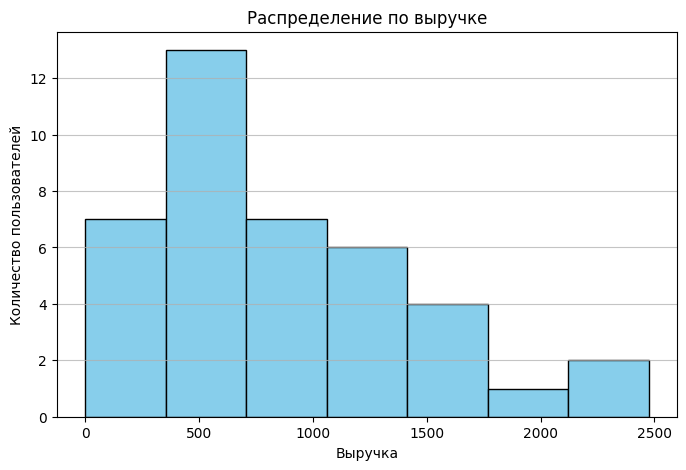

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df['revenue'], bins='auto', color='skyblue', edgecolor='black')
plt.xlabel('Выручка')
plt.ylabel('Количество пользователей')
plt.title('Распределение по выручке')
plt.grid(axis='y', alpha=0.75)
plt.savefig('./figures/revenue_hist.png',dpi=500)
plt.show()

<Figure size 800x500 with 0 Axes>

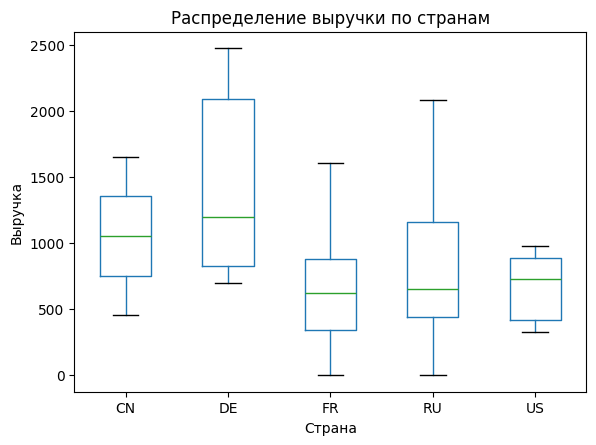

In [24]:
plt.figure(figsize=(8,5))
df.boxplot(column='revenue', by='country', grid=False)
plt.xlabel('Страна')
plt.ylabel('Выручка')
plt.title('Распределение выручки по странам')
plt.suptitle('')  # чтобы убрать автоматически добавленный заголовок
plt.savefig('./figures/countries_revenue_boxplot.png',dpi=500)
plt.show()


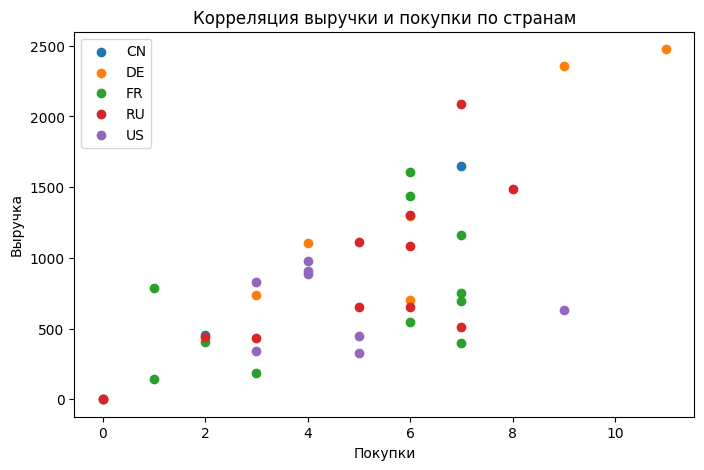

In [25]:
plt.figure(figsize=(8,5))
for country, group in df.groupby('country'):
    plt.scatter(group['purchases'], group['revenue'], label=country)
plt.xlabel('Покупки')
plt.ylabel('Выручка')
plt.title('Корреляция выручки и покупки по странам')
plt.legend()
plt.savefig('./figures/revenue_purchases_scatter.png',dpi=500)
plt.show()

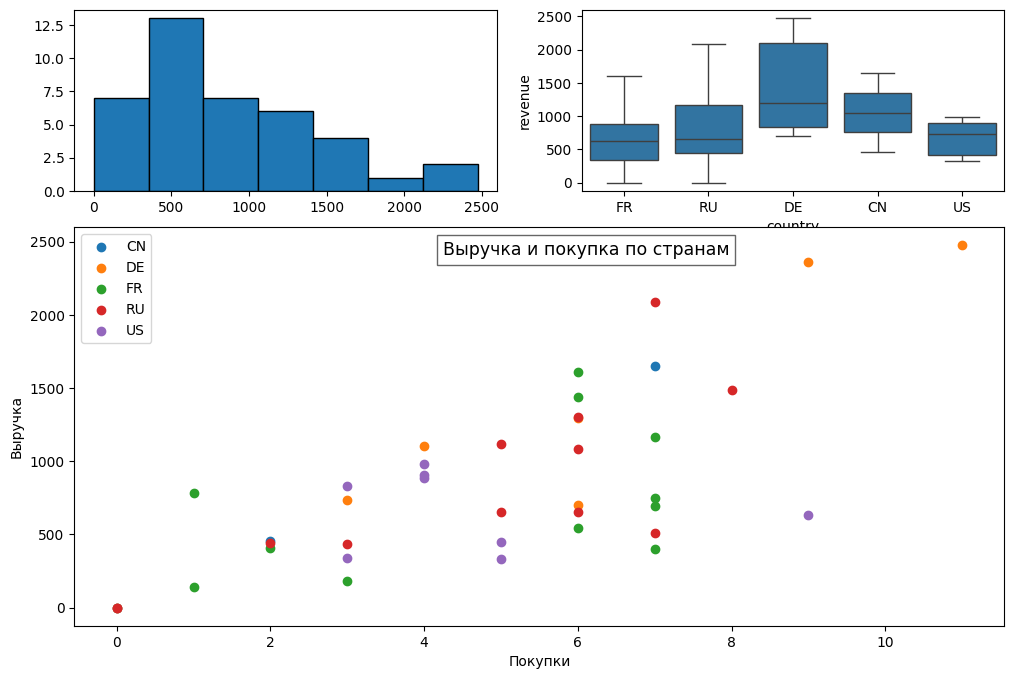

In [26]:
# Создаем полотно и subplot
fig = plt.figure(figsize=(12,8))
ax1 = plt.subplot2grid((3,2),(0,0))
ax2 = plt.subplot2grid((3,2),(0,1))
ax3 = plt.subplot2grid((3,2),(1,0),rowspan=2,colspan=2)

ax1.hist(df['revenue'],bins='auto',edgecolor='black')
sns.boxplot(data=df,x='country',y='revenue',ax=ax2)
for country, group in df.groupby('country'):
    ax3.scatter(group['purchases'], group['revenue'], label=country)
ax3.set_xlabel('Покупки')
ax3.set_ylabel('Выручка')
ax3.text(.55, .93, 'Выручка и покупка по странам', # она распологает текстовое окно
        horizontalalignment='center', # с расположением текста по центру
        transform=ax3.transAxes, # "оси" для текста
        bbox=dict(facecolor='white', alpha=0.6), # очерчивание текста прямоугольником
        fontsize=12.5)
plt.legend()
plt.show()

### **1. Распределение выручки по странам (Box Plot)**

График показывает статистическое распределение выручки для пяти стран: CN, DE, FR, RU, US.

**Самая высокая медианная выручка:** У Германии (DE) и России (RU) медиана выручки (зеленая линия в коробке) находится на уровне примерно 1200-1300 единиц, что является самым высоким значением среди всех стран.
**Наибольший разброс данных:** У Германии (DE) наблюдается самый широкий диапазон выручки — от минимума около 700 до максимума почти 2500. Это указывает на большую вариативность в доходах пользователей из этой страны.
**Наименьший разброс данных:** У США (US) разброс выручки самый маленький — от минимума около 100 до максимума около 1000. Данные здесь наиболее сконцентрированы.
**Средний уровень выручки:** Китай (CN) и Франция (FR) имеют схожие медианные значения выручки (около 1000), но у Франции более широкий разброс.
**Высокие выбросы:** В Германии и России есть точки, выходящие за верхнюю границу "усов" (выше 2000), что может указывать на наличие пользователей с аномально высокой выручкой.

### **2. Распределение по выручке (Гистограмма)**

Показывает, какое количество пользователей приходится на определенные диапазоны выручки.

**Пиковая группа пользователей:** Наибольшее количество пользователей (14 человек) имеет выручку в диапазоне от 500 до 1000 единиц.
**Распределение по убыванию:** По мере увеличения выручки количество пользователей уменьшается. Например, 8 пользователей имеют выручку от 0 до 500, 6 — от 1000 до 1500, 4 — от 1500 до 2000.
**Малочисленные группы с высокой выручкой:** Только 2 пользователя имеют выручку выше 2000 единиц, что подтверждает наблюдение о наличии выбросов в box plot'ах для некоторых стран.
**Общий тренд:** Распределение выручки является правосторонним (с перекосом вправо) — большинство пользователей генерируют небольшую выручку, а небольшая часть — очень высокую.

### **3. Корреляция выручки и покупки по странам (Scatter Plot)**

Этот график демонстрирует связь между количеством покупок (ось X) и выручкой (ось Y) для каждого пользователя, сгруппированных по странам.

**Общая положительная корреляция:** Визуально видна общая тенденция: чем больше покупок совершает пользователь, тем выше его выручка. Точки в основном располагаются по диагонали снизу вверх.
**Страновые различия:**
**Германия (DE, оранжевые точки):** Имеет самые высокие значения как по выручке (до 2500), так и по количеству покупок (до 11). Пользователи этой страны являются самыми активными и прибыльными.
**Россия (RU, красные точки):** Также показывает высокие значения выручки (до 2100) и количество покупок (до 8), но в целом немного ниже, чем у Германии.
**Китай (CN, синие точки):** Пользователи совершают меньше покупок (максимум 7), но при этом могут генерировать высокую выручку (до 1700), что говорит о том, что их покупки, возможно, дороже.
**Франция (FR, зеленые точки):** Показывают средние значения по обоим параметрам.
**США (US, фиолетовые точки):** Пользователи совершают относительно много покупок (до 9), но выручка у них невысокая (максимум около 1000), что может свидетельствовать о более низкой стоимости покупок.


### **Общие выводы**

**Германия и Россия** являются ключевыми рынками с точки зрения генерации выручки, несмотря на то, что у Германии также наблюдается наибольшая вариативность доходов.
**США** отличаются высокой частотой покупок, но низкой стоимостью каждой покупки.
**Китай** демонстрирует потенциал к высокой выручке при меньшем количестве покупок.
**Большинство пользователей** генерируют умеренную выручку (до 1000), и лишь небольшая доля пользователей ответственна за высокую выручку (свыше 2000).
Между количеством покупок и общей выручкой существует положительная связь, однако эта связь варьируется в зависимости от страны, что указывает на различия в поведении потребителей и ценовой политике.